## Підготовка середовища

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

sns.set_theme(style="whitegrid")

## Завантаження даних

In [4]:
print("Завантаження датасету Communities and Crime...")
dataset = fetch_ucirepo(id=183)

df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)

print(f"Початковий розмір даних: {df.shape}")

Завантаження датасету Communities and Crime...
Початковий розмір даних: (1994, 128)


## Data Cleaning

In [5]:
print(f"Початковий розмір даних: {df.shape}")
print("Очищення даних...")

# видалити колонки з >50% пропущених значень
threshold = len(df) * 0.5
df_clean = df.dropna(thresh=threshold, axis=1).copy()

# заповнюємо пропуски медіанним значенням
num_cols = df_clean.select_dtypes(include=['number']).columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# видаляємо залишкові рядки з текстовими пропусками
df_clean.dropna(inplace=True)

print(f"Розмір після очищення: {df_clean.shape}")

Початковий розмір даних: (1994, 128)
Очищення даних...
Розмір після очищення: (1994, 128)


## Базові візуалізації (3-4)

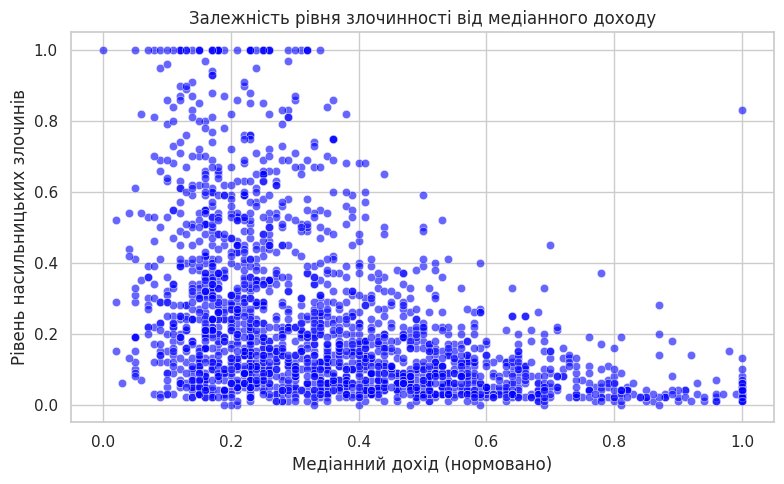

In [6]:
# --- 3. Залежність одного атрибута від іншого ---
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='medIncome', y='ViolentCrimesPerPop', alpha=0.6, color='blue')
plt.title('Залежність рівня злочинності від медіанного доходу')
plt.xlabel('Медіанний дохід (нормовано)')
plt.ylabel('Рівень насильницьких злочинів')
plt.tight_layout()
plt.show()

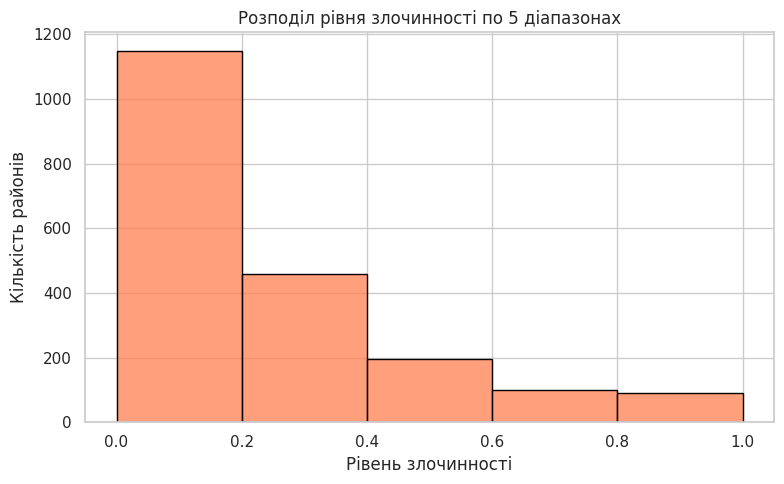

In [7]:
# --- 4. Гістограма у 5 заданих діапазонах ---
plt.figure(figsize=(8, 5))
# Задаємо 5 чітких діапазонів (bins) від 0 до 1, дані нормовані
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
sns.histplot(df_clean['ViolentCrimesPerPop'], bins=bins, color='coral', edgecolor='black')
plt.title('Розподіл рівня злочинності по 5 діапазонах')
plt.xlabel('Рівень злочинності')
plt.ylabel('Кількість районів')
plt.tight_layout()
plt.show()

## Багатовимірні графіки (5)

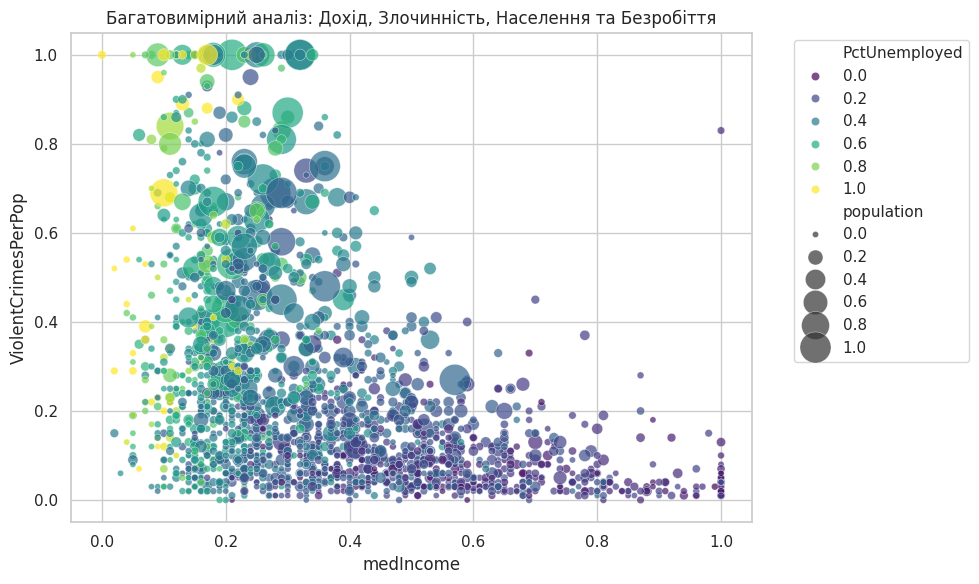

In [8]:
# Графік 5.1: Bubble Chart (4 виміри: x, y, колір, розмір)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean,
                x='medIncome',
                y='ViolentCrimesPerPop',
                size='population',
                hue='PctUnemployed',
                sizes=(20, 500),
                palette='viridis',
                alpha=0.7)
plt.title('Багатовимірний аналіз: Дохід, Злочинність, Населення та Безробіття')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

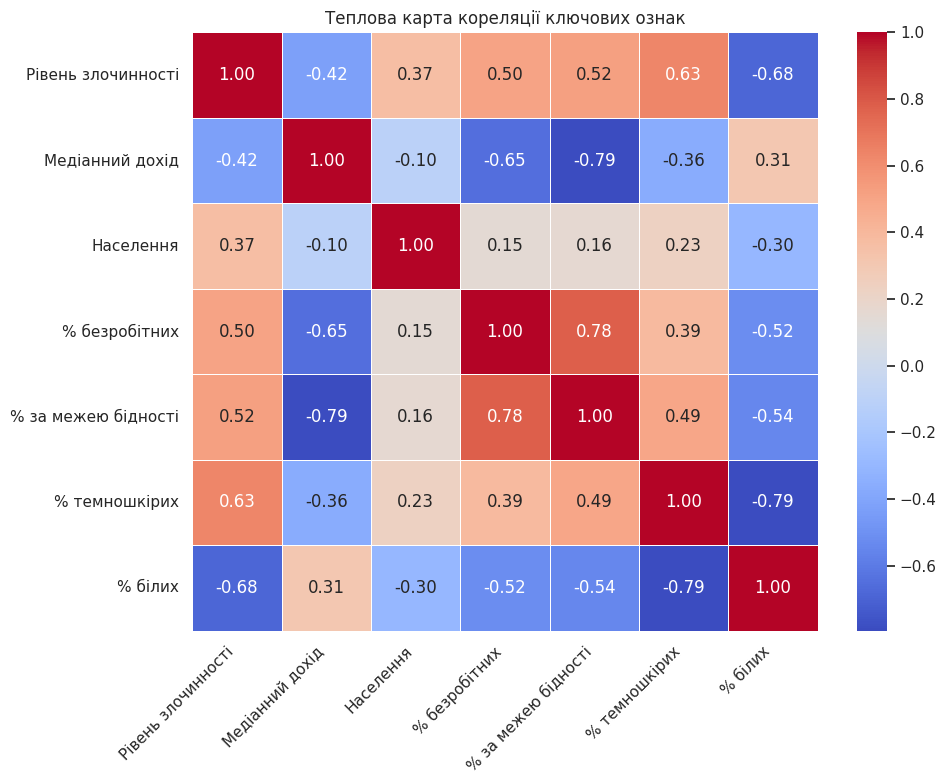

In [9]:
# Графік 5.2: Correlation Heatmap (Теплова карта кореляції)
plt.figure(figsize=(10, 8))

# Словник для перекладу колонок
ukr_names = {
    'ViolentCrimesPerPop': 'Рівень злочинності',
    'medIncome': 'Медіанний дохід',
    'population': 'Населення',
    'PctUnemployed': '% безробітних',
    'PctPopUnderPov': '% за межею бідності',
    'racepctblack': '% темношкірих',
    'racePctWhite': '% білих'
}

cols_for_heatmap = list(ukr_names.keys())

# перейменовуючи колонки
corr_matrix = df_clean[cols_for_heatmap].rename(columns=ukr_names).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Теплова карта кореляції ключових ознак')

# повертаємо підписи по осі X на 45 градусів
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Додаткові метрики (6.1, 6.2)

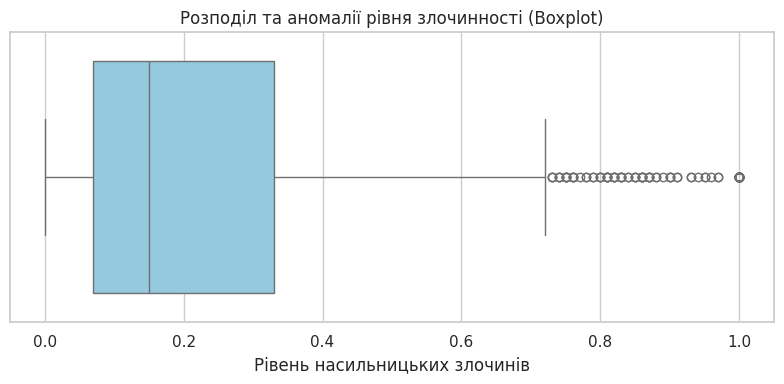

In [10]:
# Графік 6.1: Boxplot для пошуку аномалій
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean['ViolentCrimesPerPop'], color='skyblue')
plt.title('Розподіл та аномалії рівня злочинності (Boxplot)')
plt.xlabel('Рівень насильницьких злочинів')
plt.tight_layout()
plt.show()

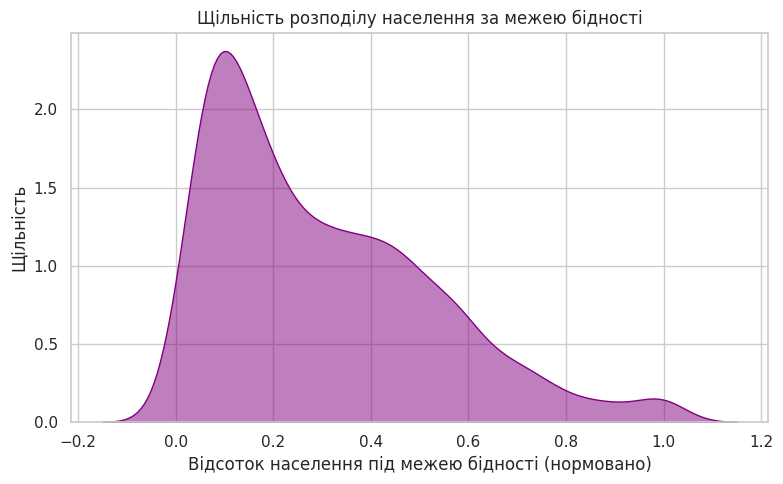

In [11]:
# Графік 6.2: Графік щільності (KDE Plot)
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_clean, x='PctPopUnderPov', fill=True, color='purple', alpha=0.5)
plt.title('Щільність розподілу населення за межею бідності')
plt.xlabel('Відсоток населення під межею бідності (нормовано)')
plt.ylabel('Щільність')
plt.tight_layout()
plt.show()